# Laboratorio ENEIC Notebook 04: Pipeline de Random Forest

Este notebook cubre el **punto 6** del laboratorio. Lee el Parquet de 2025 generado por `01_carga_calidad.ipynb` y, para comparar, el mejor modelo lineal guardado por `03_regresion_lineal.ipynb`.

* Mismo objetivo (`salario_mensual` en quetzales, sin transformar), mismos seis predictores y **mismos conjuntos**: entrenamiento I–III de 2025 y validación IV de 2025.
* I de 2026 queda reservado para el punto 7; este notebook no lo lee.
* Todas las etapas del pipeline se ajustan **solo** con entrenamiento y el bosque usa una **semilla fija**.
* Los modelos y las métricas son **no ponderados**.

## 0. Preparación

In [1]:
import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pyspark
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("Lab ENEIC - 04 Random Forest")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)

BASE_DIR  = Path(os.environ.get("LAB_BASE_DIR", "/opt/app"))
OUT_DIR   = BASE_DIR / "working_dir" / "eneic_parquet"
MODEL_DIR = OUT_DIR / "modelos"
RUTA_LR   = MODEL_DIR / "lr_mejor_pipeline"
if not RUTA_LR.exists():
    raise FileNotFoundError("No se encontró el modelo lineal. Ejecute primero 03_regresion_lineal.ipynb.")
CONFIG_LR = json.loads((MODEL_DIR / "lr_mejor_config.json").read_text())

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
SEED = 42
def q(x):
    return f"−Q{abs(x):,.0f}" if x < 0 else f"Q{x:,.0f}"
fmt_q = mtick.FuncFormatter(lambda x, _: q(x))
COLOR_REF, COLOR_LR, COLOR_RF = "#8a8984", "#2a78d6", "#eb6834"

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/26 21:21:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


## 1. Mismos conjuntos de entrenamiento y validación

Se reconstruye la partición con las mismas reglas del notebook 03 y se verifica que el número de registros coincida con el documentado junto al modelo lineal.

In [2]:
OBJETIVO    = "salario_mensual"
NUMERICAS   = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
PREDICTORES = NUMERICAS + CATEGORICAS
AUDITORIA   = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
DESCRIPCION = ["nivel_educativo_desc", "categoria_ocupacional_desc", "dominio_desc"]
PERIODOS_TRAIN = ["2025T1", "2025T2", "2025T3"]
PERIODO_VALID  = "2025T4"

df = spark.read.parquet(str(OUT_DIR / "eneic_2025_preparado.parquet"))
columnas = AUDITORIA + PREDICTORES + DESCRIPCION + [OBJETIVO]
train = df.filter(F.col("periodo_archivo").isin(PERIODOS_TRAIN)).select(*columnas).cache()
valid = df.filter(F.col("periodo_archivo") == PERIODO_VALID).select(*columnas)

personas_train = train.select("NUM_HOGAR", "NUM_PERSONA").distinct().withColumn("_vista", F.lit(True))
valid = (valid.join(personas_train, ["NUM_HOGAR", "NUM_PERSONA"], "left")
              .withColumn("persona_en_train", F.coalesce(F.col("_vista"), F.lit(False)))
              .drop("_vista")
              .cache())

N_TRAIN, N_VALID = train.count(), valid.count()
assert N_TRAIN == CONFIG_LR["entrenamiento"]["registros"] and N_VALID == CONFIG_LR["validacion"]["registros"]
assert CONFIG_LR["predictores"] == {"numericas": NUMERICAS, "categoricas": CATEGORICAS}
print(f"Entrenamiento ({', '.join(PERIODOS_TRAIN)}): {N_TRAIN:,} registros")
print(f"Validación ({PERIODO_VALID}): {N_VALID:,} registros  -> coinciden con el notebook 03")

Entrenamiento (2025T1, 2025T2, 2025T3): 40,361 registros
Validación (2025T4): 12,664 registros  -> coinciden con el notebook 03


In [3]:
METRICAS = ["mae", "rmse", "r2"]
EVALUADORES = {m: RegressionEvaluator(labelCol=OBJETIVO, predictionCol="prediction", metricName=m) for m in METRICAS}

def evaluar(pred):
    return {m: EVALUADORES[m].evaluate(pred) for m in METRICAS}

# Modelo de referencia: constante calculada con entrenamiento (igual que en el notebook 03)
media_train, mediana_train = train.agg(F.mean(OBJETIVO), F.expr(f"percentile({OBJETIVO}, 0.5)")).first()
ref_valid = {
    "Referencia: media de entrenamiento": evaluar(valid.withColumn("prediction", F.lit(float(media_train)))),
    "Referencia: mediana de entrenamiento": evaluar(valid.withColumn("prediction", F.lit(float(mediana_train)))),
}
display(pd.DataFrame(ref_valid).T.round(4))

,mae,rmse,r2
Referencia: media de entrenamiento,1672.5026,2889.5714,-0.0031
Referencia: mediana de entrenamiento,1670.3902,2936.0039,-0.0356


## 2. Pipeline de Random Forest

| Etapa | Componente | Detalle |
|---|---|---|
| a | `StringIndexer` (×3) + `OneHotEncoder` | Igual que en la regresión lineal: `nivel_educativo`, `categoria_ocupacional` y `dominio` → índices → vectores binarios. `handleInvalid="keep"` en los indexadores. |
| b | `VectorAssembler` | `edad`, `antiguedad`, `horas_semanales` + las tres variables codificadas → `features`. |
| c | `RandomForestRegressor` | Promedia muchos árboles de regresión, cada uno entrenado con una muestra *bootstrap* y con un subconjunto aleatorio de predictores en cada división (`featureSubsetStrategy="auto"`, que en regresión equivale a un tercio de las columnas). `seed = 42`. |

Los árboles dividen por umbrales, así que el resultado no cambia si una variable se multiplica por una constante: **no se estandariza**. Los tres primeros pasos son idénticos a los del notebook 03, por lo que ambos modelos reciben exactamente el mismo vector de predictores.

In [4]:
def etapas_preparacion():
    indexadores = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAS]
    codificador = OneHotEncoder(inputCols=[f"{c}_idx" for c in CATEGORICAS],
                                outputCols=[f"{c}_ohe" for c in CATEGORICAS])
    ensamblador = VectorAssembler(inputCols=NUMERICAS + [f"{c}_ohe" for c in CATEGORICAS], outputCol="features")
    return indexadores + [codificador, ensamblador]

def pipeline_rf(numTrees, maxDepth):
    rf = RandomForestRegressor(featuresCol="features", labelCol=OBJETIVO, predictionCol="prediction",
                               numTrees=numTrees, maxDepth=maxDepth, featureSubsetStrategy="auto",
                               subsamplingRate=1.0, minInstancesPerNode=1, maxBins=32, seed=SEED)
    return Pipeline(stages=etapas_preparacion() + [rf])

prep_modelo = Pipeline(stages=etapas_preparacion()).fit(train)
atributos = prep_modelo.transform(train.limit(1)).schema["features"].metadata["ml_attr"]["attrs"]
NOMBRES_FEATURES = [a["name"] for a in sorted(sum(atributos.values(), []), key=lambda a: a["idx"])]
print(f"Dimensión del vector de predictores: {len(NOMBRES_FEATURES)} (la misma que en la regresión lineal)")

Dimensión del vector de predictores: 18 (la misma que en la regresión lineal)


## 3. Configuraciones probadas

Se varían los dos hiperparámetros que más influyen en la capacidad del bosque:

* `numTrees` ∈ {50, 150}: más árboles reducen la varianza del promedio, con rendimientos decrecientes.
* `maxDepth` ∈ {5, 10, 15, 20}: árboles más profundos capturan interacciones más finas (por ejemplo, educación × categoría ocupacional × edad), pero pueden memorizar el entrenamiento.

El resto queda fijo (`minInstancesPerNode = 1`, `subsamplingRate = 1.0`, `maxBins = 32`, `seed = 42`). Son 8 configuraciones; se elige la de **menor RMSE de validación** sobre todos los registros de IV 2025. Como diagnóstico adicional (no como criterio de selección) se reporta el RMSE por separado para las personas de validación que ya aparecían en entrenamiento y para las nuevas: si un bosque mejora solo en las personas ya vistas, estaría aprovechando la repetición del panel más que aprendiendo patrones generalizables.

In [5]:
CONFIGS_RF = [{"numTrees": n, "maxDepth": d} for n in [50, 150] for d in [5, 10, 15, 20]]

resultados, modelos = [], {}
for i, cfg in enumerate(CONFIGS_RF):
    t0 = time.time()
    modelo = pipeline_rf(**cfg).fit(train)
    segundos = time.time() - t0
    m_train = evaluar(modelo.transform(train))
    pred_v = modelo.transform(valid).cache()
    m_valid = evaluar(pred_v)
    rmse_vistas = EVALUADORES["rmse"].evaluate(pred_v.filter(F.col("persona_en_train")))
    rmse_nuevas = EVALUADORES["rmse"].evaluate(pred_v.filter(~F.col("persona_en_train")))
    pred_v.unpersist()
    modelos[i] = modelo
    resultados.append({
        "config": i, **cfg,
        **{f"{m}_train": v for m, v in m_train.items()},
        **{f"{m}_valid": v for m, v in m_valid.items()},
        "rmse_valid_vistas": rmse_vistas, "rmse_valid_nuevas": rmse_nuevas,
        "nodos_totales": sum(t.numNodes for t in modelo.stages[-1].trees),
        "segundos": round(segundos, 1),
    })
    print(f"config {i}: {cfg} -> RMSE validación = Q{m_valid['rmse']:,.1f} ({segundos:.0f} s)")

res_rf = pd.DataFrame(resultados)
res_rf.to_csv(OUT_DIR / "rf_configuraciones_validacion.csv", index=False)
display(res_rf.sort_values("rmse_valid").round(4))

config 0: {'numTrees': 50, 'maxDepth': 5} -> RMSE validación = Q2,167.1 (5 s)


config 1: {'numTrees': 50, 'maxDepth': 10} -> RMSE validación = Q1,989.7 (9 s)


config 2: {'numTrees': 50, 'maxDepth': 15} -> RMSE validación = Q1,925.5 (37 s)


config 3: {'numTrees': 50, 'maxDepth': 20} -> RMSE validación = Q1,906.2 (75 s)


config 4: {'numTrees': 150, 'maxDepth': 5} -> RMSE validación = Q2,158.7 (6 s)


config 5: {'numTrees': 150, 'maxDepth': 10} -> RMSE validación = Q1,981.9 (34 s)


config 6: {'numTrees': 150, 'maxDepth': 15} -> RMSE validación = Q1,913.9 (143 s)


config 7: {'numTrees': 150, 'maxDepth': 20} -> RMSE validación = Q1,895.8 (235 s)


,config,numTrees,maxDepth,mae_train,rmse_train,r2_train,mae_valid,rmse_valid,r2_valid,rmse_valid_vistas,rmse_valid_nuevas,nodos_totales,segundos
7,7,150,20,939.9703,1727.1033,0.6469,1026.3551,1895.7759,0.5682,1820.7293,2058.2906,959310,235.0
3,3,50,20,941.8375,1747.4756,0.6385,1030.7130,1906.2416,0.5634,1832.1068,2066.9483,326150,74.9
6,6,150,15,985.4010,1777.3362,0.6260,1041.7954,1913.8610,0.5599,1847.9586,2057.6786,565674,142.8
2,2,50,15,988.5689,1797.8013,0.6174,1047.4175,1925.4771,0.5546,1860.0726,2068.3081,188742,37.4
5,5,150,10,1070.0861,1936.6638,0.5560,1075.6439,1981.8515,0.5281,1942.2845,2070.1351,126256,33.6
1,1,50,10,1070.9634,1945.5556,0.5519,1078.7869,1989.6609,0.5244,1951.0314,2075.9267,42512,9.1
4,4,150,5,1178.3798,2201.0526,0.4265,1158.0399,2158.7334,0.4401,2152.7223,2172.5194,8818,5.9
0,0,50,5,1176.9319,2207.0638,0.4233,1158.9118,2167.0551,0.4358,2158.6921,2186.2013,2950,5.4


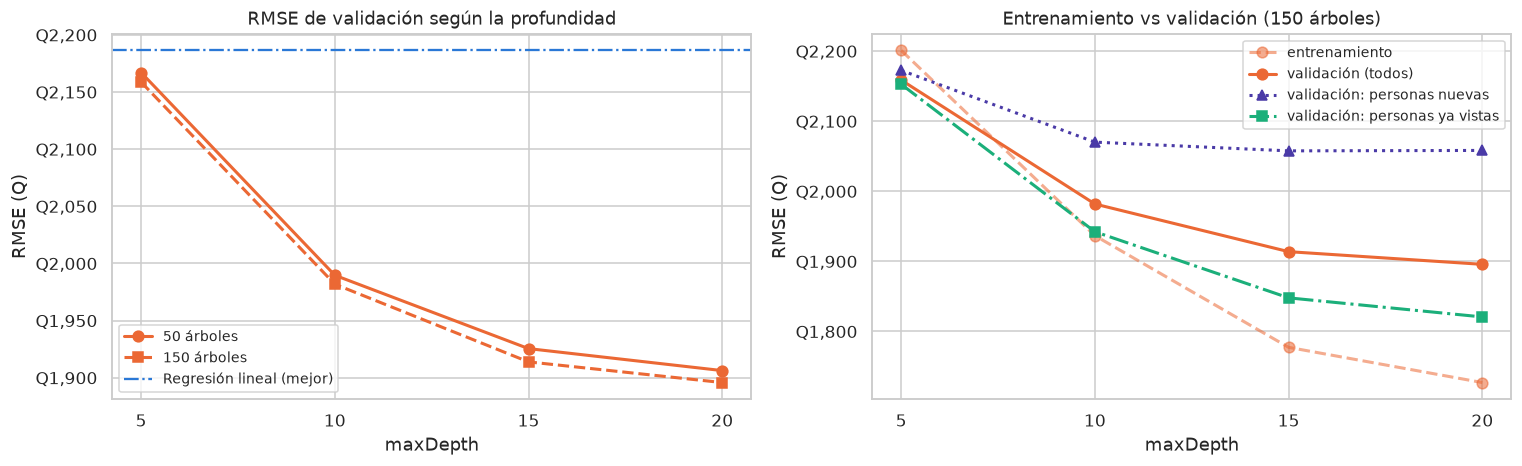

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
marcadores = {50: ("o", "-"), 150: ("s", "--")}
for n, g in res_rf.groupby("numTrees"):
    mk, ls = marcadores[n]
    axes[0].plot(g["maxDepth"], g["rmse_valid"], marker=mk, ls=ls, lw=2, ms=7, color=COLOR_RF, label=f"{n} árboles")
axes[0].axhline(CONFIG_LR["metricas_validacion"]["rmse"], color=COLOR_LR, lw=1.5, ls="-.", label="Regresión lineal (mejor)")
axes[0].set_title("RMSE de validación según la profundidad"); axes[0].legend(fontsize=9)

g = res_rf[res_rf.numTrees == res_rf.sort_values("rmse_valid").iloc[0].numTrees]
axes[1].plot(g["maxDepth"], g["rmse_train"], marker="o", ls="--", lw=2, ms=7, color=COLOR_RF, alpha=0.55, label="entrenamiento")
axes[1].plot(g["maxDepth"], g["rmse_valid"], marker="o", ls="-", lw=2, ms=7, color=COLOR_RF, label="validación (todos)")
axes[1].plot(g["maxDepth"], g["rmse_valid_nuevas"], marker="^", ls=":", lw=2, ms=7, color="#4a3aa7", label="validación: personas nuevas")
axes[1].plot(g["maxDepth"], g["rmse_valid_vistas"], marker="s", ls="-.", lw=2, ms=7, color="#1baf7a", label="validación: personas ya vistas")
axes[1].set_title(f"Entrenamiento vs validación ({int(g.numTrees.iloc[0])} árboles)"); axes[1].legend(fontsize=9)
for ax in axes:
    ax.set_xlabel("maxDepth"); ax.set_ylabel("RMSE (Q)"); ax.set_xticks([5, 10, 15, 20])
    ax.yaxis.set_major_formatter(fmt_q)
plt.tight_layout(); plt.show()

**Interpretación.**

* **La profundidad es el hiperparámetro decisivo.** Al pasar de profundidad 5 a 10, el RMSE de validación baja de unos Q2,160 a unos Q1,985, y sigue bajando con 15 y 20 hasta Q1,896. Con profundidad 5, el bosque apenas supera a la regresión lineal (Q2,159 frente a Q2,186): con tan pocas divisiones no alcanza a representar las combinaciones de variables.
* **El número de árboles importa poco.** Con la misma profundidad, 150 árboles mejoran a 50 en solo Q8–12 de RMSE, a cambio de triplicar el tiempo de entrenamiento y el número de nodos. El promedio de 50 árboles ya es bastante estable.
* **El sobreajuste crece con la profundidad.** Con profundidad 5, el RMSE de entrenamiento (Q2,201) es incluso mayor que el de validación. Con profundidad 20, en cambio, es de Q1,727 frente a Q1,896 en validación.
* **La mejora de los árboles profundos viene de las personas repetidas.** Para las personas **nuevas** en IV de 2025, el RMSE deja de mejorar después de la profundidad 15 (Q2,058 con 15 y con 20, frente a Q2,070 con 10). Para las personas **ya vistas** en entrenamiento, sigue bajando (de Q1,848 a Q1,821). Los árboles profundos aíslan combinaciones muy específicas de edad, antigüedad, horas, educación, categoría y dominio, y esas combinaciones prácticamente identifican a una persona que se repite en el panel: el bosque “recuerda” el salario que reportó en otro trimestre. Por eso, parte de la ventaja en validación es memoria del panel y no un patrón que se generalice a personas nuevas.
* **Elección.** Siguiendo el criterio del enunciado, se selecciona la configuración con menor RMSE de validación: **150 árboles y profundidad 20** (Q1,895.8). Está en el borde de la cuadrícula, pero no se amplió porque, más allá de la profundidad 15, las ganancias provienen solo de personas repetidas. Una alternativa defendible es 150 árboles con profundidad 15: rinde igual en personas nuevas con 41 % menos nodos. Se deja documentada como análisis de sensibilidad para el punto 7.

## 4. Configuración seleccionada y comparación con la regresión lineal y la referencia

El modelo lineal se **carga desde disco** (guardado por el notebook 03) y se evalúa de nuevo sobre los mismos registros de validación, de modo que las cuatro filas de la tabla se calculan aquí sobre exactamente los mismos datos.

In [7]:
mejor = res_rf.sort_values(["rmse_valid", "numTrees", "maxDepth"]).iloc[0]
MEJOR_CFG = {"numTrees": int(mejor.numTrees), "maxDepth": int(mejor.maxDepth)}
modelo_rf = modelos[int(mejor.config)]
modelo_lr = PipelineModel.load(str(RUTA_LR))
print("Random Forest seleccionado (menor RMSE de validación):", MEJOR_CFG)
print("Regresión lineal cargada del notebook 03:", CONFIG_LR["hiperparametros"])

pred_rf = modelo_rf.transform(valid).withColumn("residuo", F.col(OBJETIVO) - F.col("prediction")).cache()
pred_lr = modelo_lr.transform(valid).withColumn("residuo", F.col(OBJETIVO) - F.col("prediction")).cache()
m_lr = evaluar(pred_lr)
assert abs(m_lr["rmse"] - CONFIG_LR["metricas_validacion"]["rmse"]) < 1e-6

comparacion = pd.DataFrame({
    **ref_valid,
    f"Regresión lineal (λ={CONFIG_LR['hiperparametros']['regParam']:g}, α={CONFIG_LR['hiperparametros']['elasticNetParam']:g})": m_lr,
    f"Random Forest ({MEJOR_CFG['numTrees']} árboles, prof. {MEJOR_CFG['maxDepth']})": evaluar(pred_rf),
}).T.rename(columns={"mae": "MAE", "rmse": "RMSE", "r2": "R²"})
ref = comparacion.iloc[0]
comparacion["MAE vs media (%)"]  = 100 * (comparacion["MAE"] / ref["MAE"] - 1)
comparacion["RMSE vs media (%)"] = 100 * (comparacion["RMSE"] / ref["RMSE"] - 1)
print(f"Métricas en validación (IV 2025, n = {N_VALID:,}):")
display(comparacion.round(3))
comparacion.to_csv(OUT_DIR / "comparacion_validacion_2025T4.csv")

print("Random Forest: entrenamiento vs validación")
display(pd.DataFrame({"entrenamiento": mejor[["mae_train", "rmse_train", "r2_train"]].values,
                      "validación": mejor[["mae_valid", "rmse_valid", "r2_valid"]].values},
                     index=["MAE", "RMSE", "R²"]).astype(float).round(3))

Random Forest seleccionado (menor RMSE de validación): {'numTrees': 150, 'maxDepth': 20}
Regresión lineal cargada del notebook 03: {'regParam': 0.0, 'elasticNetParam': 0.0, 'standardization': True, 'fitIntercept': True, 'maxIter': 200}


Métricas en validación (IV 2025, n = 12,664):


,MAE,RMSE,R²,MAE vs media (%),RMSE vs media (%)
Referencia: media de entrenamiento,1672.503,2889.571,-0.003,0.000,0.000
Referencia: mediana de entrenamiento,1670.390,2936.004,-0.036,-0.126,1.607
"Regresión lineal (λ=0, α=0)",1210.137,2186.420,0.426,-27.645,-24.334
"Random Forest (150 árboles, prof. 20)",1026.355,1895.776,0.568,-38.634,-34.392


Random Forest: entrenamiento vs validación


,entrenamiento,validación
MAE,939.970,1026.355
RMSE,1727.103,1895.776
R²,0.647,0.568


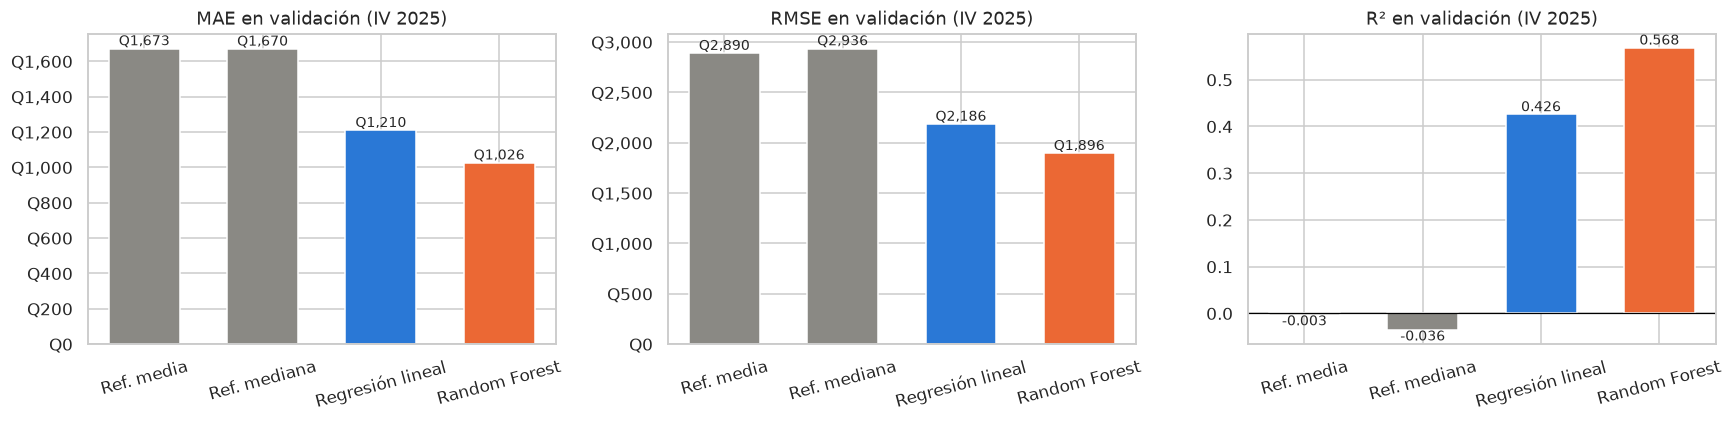

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
nombres = ["Ref. media", "Ref. mediana", "Regresión lineal", "Random Forest"]
colores = [COLOR_REF, COLOR_REF, COLOR_LR, COLOR_RF]
for ax, m in zip(axes, ["MAE", "RMSE", "R²"]):
    vals = comparacion[m].values
    ax.bar(nombres, vals, color=colores, width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v, q(v) if m != "R²" else f"{v:.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    ax.set_title(f"{m} en validación (IV 2025)"); ax.axhline(0, color="black", lw=0.8)
    ax.tick_params(axis="x", rotation=15)
    if m != "R²":
        ax.yaxis.set_major_formatter(fmt_q)
plt.tight_layout(); plt.show()

**Interpretación.** El Random Forest seleccionado (150 árboles, profundidad 20) es el mejor de los cuatro modelos en validación, con las tres métricas:

* **MAE = Q1,026:** 39 % menos que la referencia y 15 % menos que la regresión lineal (Q1,210).
* **RMSE = Q1,896:** 34 % menos que la referencia y 13 % menos que la regresión lineal (Q2,186).
* **R² = 0.568**, frente a 0.426 de la regresión lineal: explica 14 puntos porcentuales más de la variación del salario.
* **Sobreajuste moderado.** El RMSE de entrenamiento del bosque (Q1,727) es 9 % menor que el de validación, mientras que en la regresión lineal ocurre lo contrario. Aun así, su desempeño fuera de entrenamiento es claramente mejor.

Incluso el mejor modelo tiene un error considerable: un MAE de Q1,026 equivale a un 32 % del salario mediano de validación (Q3,200). Además, el RMSE sigue siendo casi el doble del MAE, lo que indica que los salarios altos siguen generando los errores más grandes.

## 5. ¿Qué diferencias explican el desempeño?

Se comparan ambos modelos en validación desde cuatro ángulos: qué variables usa el bosque, qué rango de valores puede predecir cada modelo, cómo se reparte el error por tramos de salario y por categoría ocupacional, y si el error cambia entre personas ya vistas en entrenamiento y personas nuevas.

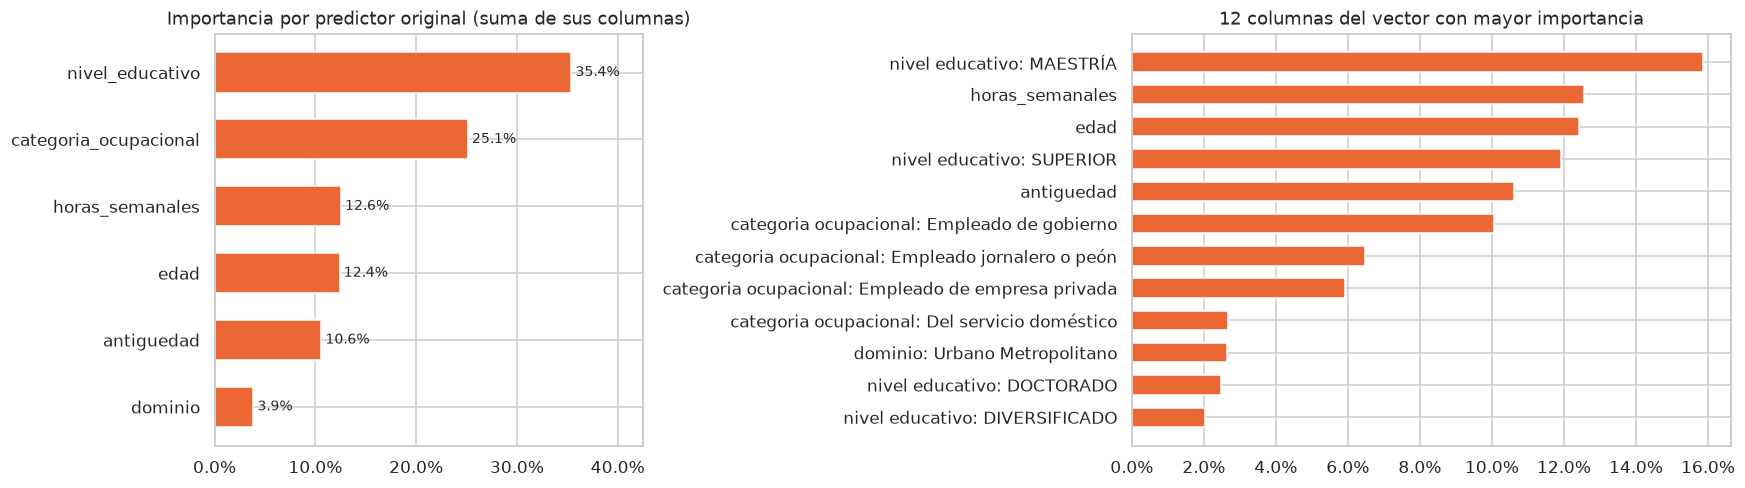

,importancia_%
predictor,
nivel_educativo,35.4
categoria_ocupacional,25.1
horas_semanales,12.6
edad,12.4
antiguedad,10.6
dominio,3.9


In [9]:
etiquetas = {}
for c, dc in zip(CATEGORICAS, DESCRIPCION):
    for fila in df.select(c, dc).distinct().collect():
        etiquetas[f"{c}_ohe_{fila[c]}"] = f"{c.replace('_', ' ')}: {fila[dc]}"

rf_final = modelo_rf.stages[-1]
imp = pd.DataFrame({"variable": NOMBRES_FEATURES, "importancia": rf_final.featureImportances.toArray()})
imp["predictor"] = imp["variable"].str.replace(r"_ohe_.*$", "", regex=True)
imp["descripcion"] = imp["variable"].map(etiquetas).fillna(imp["variable"])
imp_var = imp.groupby("predictor")["importancia"].sum().sort_values()
top = imp.sort_values("importancia").tail(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].barh(imp_var.index, imp_var.values, color=COLOR_RF, height=0.6)
for i, v in enumerate(imp_var.values):
    axes[0].text(v, i, f" {100 * v:.1f}%", va="center", fontsize=9)
axes[0].set_title("Importancia por predictor original (suma de sus columnas)"); axes[0].set_xlim(0, imp_var.max() * 1.2)
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].barh(top["descripcion"], top["importancia"], color=COLOR_RF, height=0.6)
axes[1].set_title("12 columnas del vector con mayor importancia")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout(); plt.show()
display((100 * imp_var.sort_values(ascending=False)).round(1).rename("importancia_%").to_frame())

In [10]:
# Rango de valores que produce cada modelo frente al salario real (todos los registros de validación)
def distribucion(d, col):
    q = d.agg(F.min(col), F.expr(f"percentile({col}, array(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99))"), F.max(col),
              F.sum((F.col(col) < 0).cast("int"))).first()
    return [q[0], *q[1], q[2], q[3]]

dist = pd.DataFrame({
    "Salario real": distribucion(pred_lr, OBJETIVO),
    "Predicción regresión lineal": distribucion(pred_lr, "prediction"),
    "Predicción Random Forest": distribucion(pred_rf, "prediction"),
}, index=["mín", "p1", "p5", "p25", "p50", "p75", "p95", "p99", "máx", "valores < 0"]).T
display(dist.round(0))

,mín,p1,p5,p25,p50,p75,p95,p99,máx,valores < 0
Salario real,200.0,400.0,750.0,2000.0,3200.0,4000.0,8000.0,15000.0,60000.0,0.0
Predicción regresión lineal,-602.0,384.0,1057.0,2173.0,3274.0,4202.0,6450.0,10869.0,14933.0,30.0
Predicción Random Forest,321.0,577.0,1011.0,2191.0,3243.0,4111.0,7005.0,10940.0,29770.0,0.0


In [11]:
# Error por tramo del salario real (cortes = percentiles 50, 90 y 99 de ENTRENAMIENTO) y por categoría ocupacional
p50, p90, p99 = train.agg(F.expr(f"percentile({OBJETIVO}, array(0.5, 0.9, 0.99))")).first()[0]
TRAMOS = [f"1. ≤ p50 (≤ Q{p50:,.0f})", f"2. p50–p90 (Q{p50:,.0f}–{p90:,.0f}]", f"3. p90–p99 (Q{p90:,.0f}–{p99:,.0f}]", f"4. > p99 (> Q{p99:,.0f})"]
tramo = (F.when(F.col(OBJETIVO) <= p50, TRAMOS[0]).when(F.col(OBJETIVO) <= p90, TRAMOS[1])
          .when(F.col(OBJETIVO) <= p99, TRAMOS[2]).otherwise(TRAMOS[3]))

def errores_por(pred, col_grupo):
    t = (pred.groupBy(col_grupo).agg(
            F.count("*").alias("n"),
            F.mean(OBJETIVO).alias("salario_medio"),
            F.mean("prediction").alias("prediccion_media"),
            F.mean(F.abs("residuo")).alias("MAE"),
            F.mean("residuo").alias("error_medio"),
            F.sum(F.col("residuo") ** 2).alias("sse"))
         .toPandas().sort_values(col_grupo).set_index(col_grupo))
    t["RMSE"] = np.sqrt(t["sse"] / t["n"])
    t["% del error cuadrático"] = 100 * t["sse"] / t["sse"].sum()
    t["error_medio_%"] = 100 * t["error_medio"] / t["salario_medio"]
    return t.drop(columns="sse")

def comparar_por(col_grupo, preds=None):
    # Tabla larga: una fila por (modelo, grupo)
    preds = preds or {"Regresión lineal": pred_lr, "Random Forest": pred_rf}
    return pd.concat({m: errores_por(p, col_grupo) for m, p in preds.items()}, names=["modelo", col_grupo])

por_tramo = comparar_por("tramo", {"Regresión lineal": pred_lr.withColumn("tramo", tramo),
                                   "Random Forest": pred_rf.withColumn("tramo", tramo)})
por_cat = comparar_por("categoria_ocupacional_desc")
print("Error por tramo de salario real (residuo = real − predicho; positivo = subestimación):")
display(por_tramo.round(1))
print("Error por categoría ocupacional:")
display(por_cat.round(1))

Error por tramo de salario real (residuo = real − predicho; positivo = subestimación):


n  salario_medio  prediccion_media      MAE  error_medio     RMSE  % del error cuadrático  error_medio_%
modelo           tramo                                                                                                                                  
Regresión lineal 1. ≤ p50 (≤ Q3,000)         6126         1836.3            2390.0    916.2       -553.6   1229.6                    15.3          -30.1
                 2. p50–p90 (Q3,000–6,000]   5369         4075.5            4005.7    923.7         69.8   1281.7                    14.6            1.7
                 3. p90–p99 (Q6,000–15,000]  1079         8960.0            6098.2   3162.6       2861.8   3806.2                    25.8           31.9
                 4. > p99 (> Q15,000)          90        23223.4            8324.6  14898.7      14898.7  17264.5                    44.3           64.2
Random Forest    1. ≤ p50 (≤ Q3,000)         6126         1836.3            2290.9    720.6       -454.6   1024.1                    14.1          -24.8
                 2. p50–p90 (Q3,000–6,000]   5369         4075.5            4007.6    846.8         67.9   1227.1                    17.8            1.7
                 3. p90–p99 (Q6,000–15,000]  1079         8960.0            6595.4   2714.3       2364.6   3380.2                    27.1           26.4
                 4. > p99 (> Q15,000)          90        23223.4           10906.4  12317.0      12317.0  14405.5                    41.0           53.0

Error por categoría ocupacional:


n  salario_medio  prediccion_media     MAE  error_medio    RMSE  % del error cuadrático  error_medio_%
modelo           categoria_ocupacional_desc                                                                                                            
Regresión lineal Del servicio doméstico        981         1291.7            1230.9   675.9         60.9   899.8                     1.3            4.7
                 Empleado de empresa privada  7175         3910.8            3798.8  1234.5        112.0  2344.1                    65.1            2.9
                 Empleado de gobierno         1637         6073.2            5924.0  2071.5        149.2  3219.1                    28.0            2.5
                 Empleado jornalero o peón    2871         1957.2            1851.2   840.6        106.0  1081.0                     5.5            5.4
Random Forest    Del servicio doméstico        981         1291.7            1271.4   459.9         20.4   639.7                     0.9            1.6
                 Empleado de empresa privada  7175         3910.8            3802.1  1105.2        108.8  2095.7                    69.2            2.8
                 Empleado de gobierno         1637         6073.2            5952.8  1681.9        120.5  2647.3                    25.2            2.0
                 Empleado jornalero o peón    2871         1957.2            1872.9   649.1         84.3   860.7                     4.7            4.3

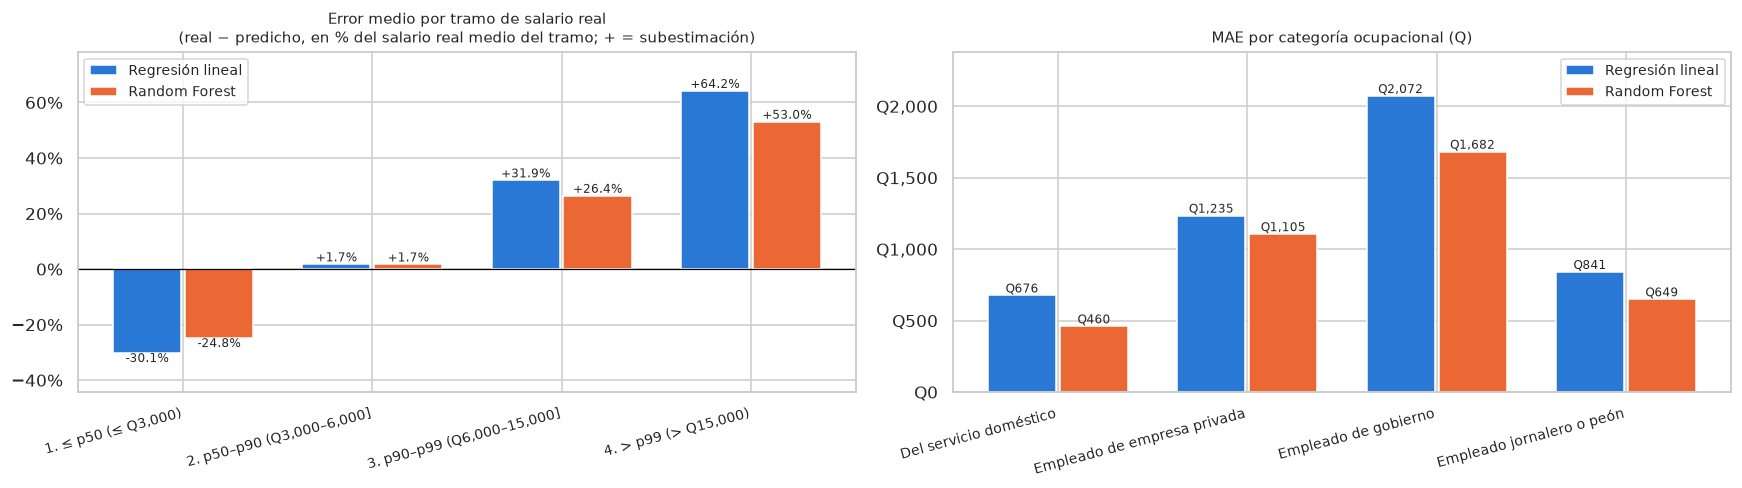

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
for ax, tabla, col, titulo in [
    (axes[0], por_tramo, "error_medio_%", "Error medio por tramo de salario real\n(real − predicho, en % del salario real medio del tramo; + = subestimación)"),
    (axes[1], por_cat, "MAE", "MAE por categoría ocupacional (Q)"),
]:
    grupos = tabla.loc["Regresión lineal"].index
    x = np.arange(len(grupos)); w = 0.38
    for j, (modelo, color) in enumerate([("Regresión lineal", COLOR_LR), ("Random Forest", COLOR_RF)]):
        vals = tabla.loc[modelo].loc[grupos, col].values
        ax.bar(x + (j - 0.5) * w, vals, width=w - 0.02, color=color, label=modelo)
        for xi, v in zip(x + (j - 0.5) * w, vals):
            ax.text(xi, v, f"{v:+.1f}%" if col.endswith("%") else q(v), ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(grupos, rotation=15, ha="right", fontsize=9)
    ax.set_title(titulo, fontsize=10); ax.legend(fontsize=9); ax.margins(y=0.15)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(100))
axes[1].yaxis.set_major_formatter(fmt_q)
plt.tight_layout(); plt.show()

In [13]:
por_persona = comparar_por("persona_en_train").rename(
    index={True: "persona vista en I–III 2025", False: "persona nueva en IV 2025"}, level=1)
display(por_persona.round(1))

n  salario_medio  prediccion_media     MAE  error_medio    RMSE  % del error cuadrático  error_medio_%
modelo           persona_en_train                                                                                                                      
Regresión lineal persona nueva en IV 2025     3833         3378.3            3291.7  1179.7         86.6  2188.5                    30.3            2.6
                 persona vista en I–III 2025  8831         3616.7            3494.5  1223.3        122.3  2185.5                    69.7            3.4
Random Forest    persona nueva en IV 2025     3833         3378.3            3264.4  1078.5        113.8  2058.3                    35.7            3.4
                 persona vista en I–III 2025  8831         3616.7            3525.8  1003.7         91.0  1820.7                    64.3            2.5

**¿Por qué el Random Forest obtiene mejores resultados en validación?**

1. **Captura interacciones y relaciones no lineales.** La regresión lineal asigna a cada categoría un efecto fijo que se suma a los demás: por ejemplo, el mismo premio por educación superior en gobierno que en servicio doméstico. El notebook 02 mostró que no es así, porque el premio educativo depende de la categoría ocupacional. Un árbol divide primero por una variable y luego por otra dentro de cada rama, así que puede representar combinaciones (educación × categoría × edad) y efectos que cambian según el rango de una variable, sin especificarlos de antemano. Por eso la mejora aparece en todas las categorías: el MAE baja 32 % en servicio doméstico, 23 % en jornaleros, 19 % en gobierno y 10 % en empresa privada.
2. **Usa las mismas variables, pero de otra forma.** Las importancias confirman lo que mostró la exploración: el nivel educativo (35 %) y la categoría ocupacional (25 %) concentran el 60 % de la importancia. Horas, edad y antigüedad aportan entre 11 % y 13 % cada una, y el dominio apenas 4 %. Las variables numéricas pesan más de lo que sugerían sus correlaciones lineales con el salario (r ≤ 0.18), porque el bosque aprovecha su relación no lineal y sus interacciones. La columna individual más importante es *maestría*, que separa el grupo con salarios más altos.
3. **Sus predicciones están acotadas.** La regresión lineal produce 30 predicciones negativas (mínimo de −Q602), imposibles para un salario, porque extrapola la recta. El Random Forest predice promedios de salarios observados en las hojas, así que siempre queda dentro del rango de entrenamiento (mínimo de Q321). En el extremo superior llega a Q29,770, mientras que la regresión lineal no pasa de Q14,933: el bosque puede asignar valores altos a combinaciones específicas de predictores.
4. **Ambos modelos tienen el mismo patrón de error, pero el bosque lo atenúa.** Los dos sobreestiman los salarios bajos y subestiman los altos, un efecto de regresión hacia la media. El Random Forest reduce ese sesgo en todos los tramos: en la mitad inferior pasa de −30 % a −25 %; en p90–p99, de +32 % a +26 %; y por encima del p99, de +64 % a +53 %. Aun así, para salarios mayores a Q15,000 predice en promedio Q10,906, frente a un valor real de Q23,223. Ninguno de los dos puede anticipar salarios muy altos con solo seis variables, y ese tramo sigue explicando el 41 % del error cuadrático del bosque.
5. **Parte de la ventaja proviene de personas repetidas.** Para las personas **nuevas** en IV de 2025, el bosque mejora a la regresión lineal en 6 % de RMSE (Q2,058 frente a Q2,189) y 9 % de MAE. Para las personas **ya vistas** en entrenamiento, la mejora llega a 17 % de RMSE (Q1,821 frente a Q2,186). La regresión lineal tiene el mismo error en ambos grupos; el bosque no. Como se vio en la sección 3, los árboles profundos aíslan combinaciones de predictores casi únicas y recuerdan el salario que esa persona declaró en otro trimestre. No es una fuga del objetivo, porque el salario de IV de 2025 no se usó para entrenar, pero sí significa que parte del desempeño del bosque depende de que el panel repita personas. Si I de 2026 comparte hogares con 2025, conviene separar este efecto al evaluar en el punto 7.

**En resumen**, el Random Forest es mejor porque su estructura flexible representa interacciones y no linealidades que el modelo lineal aditivo no puede captar, y además no produce salarios negativos. Su ventaja en personas nuevas es real pero más modesta (6–9 %). Ambos modelos comparten la misma debilidad principal: subestiman sistemáticamente los salarios altos.

## 6. Guardado del mejor modelo

Se guarda el `PipelineModel` completo de Random Forest ajustado con I–III de 2025 y un JSON con la configuración y sus métricas de validación, para que el punto 7 lo reentrene con todo 2025 y lo evalúe en I de 2026.

In [14]:
RUTA_RF = MODEL_DIR / "rf_mejor_pipeline"
modelo_rf.write().overwrite().save(str(RUTA_RF))

config_rf = {
    "algoritmo": "RandomForestRegressor",
    "hiperparametros": {**MEJOR_CFG, "featureSubsetStrategy": "auto", "subsamplingRate": 1.0,
                        "minInstancesPerNode": 1, "maxBins": 32, "seed": SEED},
    "predictores": {"numericas": NUMERICAS, "categoricas": CATEGORICAS},
    "objetivo": OBJETIVO,
    "entrenamiento": {"periodos": PERIODOS_TRAIN, "registros": N_TRAIN},
    "validacion": {"periodo": PERIODO_VALID, "registros": N_VALID},
    "metricas_validacion": {m: float(mejor[f"{m}_valid"]) for m in METRICAS},
    "configuraciones_probadas": CONFIGS_RF,
}
(MODEL_DIR / "rf_mejor_config.json").write_text(json.dumps(config_rf, ensure_ascii=False, indent=2))

recargado = PipelineModel.load(str(RUTA_RF))
m_recargado = evaluar(recargado.transform(valid))
assert all(abs(m_recargado[m] - config_rf["metricas_validacion"][m]) < 1e-6 for m in METRICAS)
print("Modelo guardado en:", RUTA_RF)
print("Métricas de validación del modelo recargado:", {m: round(v, 4) for m, v in m_recargado.items()})

Modelo guardado en: /opt/app/working_dir/eneic_parquet/modelos/rf_mejor_pipeline
Métricas de validación del modelo recargado: {'mae': 1026.3551, 'rmse': 1895.7759, 'r2': 0.5682}


## Conclusiones del punto 6

1. Se construyó el pipeline `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `RandomForestRegressor` (sin estandarización y con `seed = 42`), ajustado solo con I–III de 2025. Los conjuntos de entrenamiento y validación son los mismos que en la regresión lineal; se verificó por el número de registros.
2. Se probaron 8 configuraciones (`numTrees` ∈ {50, 150} × `maxDepth` ∈ {5, 10, 15, 20}). La profundidad es el hiperparámetro decisivo y el número de árboles cambia poco. La configuración con menor RMSE de validación es **150 árboles y profundidad 20**.
3. En validación, el bosque obtiene **MAE = Q1,026, RMSE = Q1,896 y R² = 0.568**. Supera a la regresión lineal (Q1,210; Q2,186; 0.426) y al modelo de referencia (Q1,673; Q2,890; ≈ 0). **Random Forest es el algoritmo con mejores resultados en validación.**
4. La ventaja se explica por su capacidad de representar interacciones y relaciones no lineales y por sus predicciones acotadas, sin salarios negativos. Parte de la mejora, sobre todo con árboles profundos, proviene de personas repetidas en el panel; para personas nuevas, la ventaja es de 6 % en RMSE.
5. Ambos modelos sobreestiman los salarios bajos y subestiman los altos; el error cuadrático se concentra en los salarios por encima del p99.
6. El modelo se guardó en `working_dir/eneic_parquet/modelos/rf_mejor_pipeline` y su configuración en `rf_mejor_config.json`. Para el punto 7 se sugiere reentrenar ambas configuraciones con todo 2025, evaluarlas sobre los mismos registros de I de 2026 y reportar también el error separando personas nuevas y repetidas. Como sensibilidad, puede incluirse el bosque de profundidad 15.

In [15]:
spark.catalog.clearCache()